# Legacy Morgan Fingerprint Analysis

Consolidated reproduction of the useful legacy analyses from Notebook 3 and Notebook 3-1 on the **current accepted reconstructed cohort**. Historical cohort results are shown separately for reference only.

# 1. Dataset Verification

Load the exact accepted `DILIst_Final.csv`, record its SHA-256 and schema, and verify the cohort before any analysis. The checks stop execution if the accepted input differs.

In [1]:
from pathlib import Path
import hashlib
import json
import platform

import numpy as np
import pandas as pd

# Resolve the project root whether Jupyter starts at the repository root or a child directory.
search_start = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (search_start, *search_start.parents) if (p / "DILIst_Final.csv").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate DILIst_Final.csv from the notebook working directory.")

DATA_PATH = PROJECT_ROOT / "DILIst_Final.csv"
TARGET = "DILIst Classification "
EXPECTED_SHA256 = "4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7"
EXPECTED_COLUMNS = ["DILIST_ID", "CompoundName", TARGET, "Routs of Administration ", "SMILES"]
EXPECTED_CLASS_COUNTS = {0: 463, 1: 735}

raw_bytes = DATA_PATH.read_bytes()
dataset_sha256 = hashlib.sha256(raw_bytes).hexdigest()
df = pd.read_csv(DATA_PATH)
class_counts = {int(k): int(v) for k, v in df[TARGET].value_counts().sort_index().items()}
smiles_missing = int(df["SMILES"].isna().sum())
schema = [{"column": str(c), "dtype": str(df[c].dtype), "null_count": int(df[c].isna().sum())} for c in df.columns]

verification = {
    "input_file": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "sha256": dataset_sha256,
    "rows": int(len(df)),
    "columns": schema,
    "target": TARGET,
    "class_distribution": class_counts,
    "smiles_missing": smiles_missing,
}
print(json.dumps(verification, indent=2, ensure_ascii=False))

if dataset_sha256 != EXPECTED_SHA256:
    raise RuntimeError(f"Input SHA-256 differs from the accepted dataset: {dataset_sha256}")
if len(df) != 1198:
    raise RuntimeError(f"Expected 1,198 input rows, observed {len(df)}. Stop; do not alter the cohort.")
if list(df.columns) != EXPECTED_COLUMNS:
    raise RuntimeError(f"Input schema differs from the accepted schema: {list(df.columns)}")
if class_counts != EXPECTED_CLASS_COUNTS:
    raise RuntimeError(f"Input class counts differ from the accepted counts: {class_counts}")
if smiles_missing != 0:
    raise RuntimeError(f"Expected zero missing SMILES, observed {smiles_missing}.")

print("Dataset verification passed. No historical 1,202-row cohort is loaded here.")

{
  "input_file": "DILIst_Final.csv",
  "sha256": "4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7",
  "rows": 1198,
  "columns": [
    {
      "column": "DILIST_ID",
      "dtype": "int64",
      "null_count": 0
    },
    {
      "column": "CompoundName",
      "dtype": "str",
      "null_count": 0
    },
    {
      "column": "DILIst Classification ",
      "dtype": "int64",
      "null_count": 0
    },
    {
      "column": "Routs of Administration ",
      "dtype": "str",
      "null_count": 257
    },
    {
      "column": "SMILES",
      "dtype": "str",
      "null_count": 0
    }
  ],
  "target": "DILIst Classification ",
  "class_distribution": {
    "0": 463,
    "1": 735
  },
  "smiles_missing": 0
}
Dataset verification passed. No historical 1,202-row cohort is loaded here.


# 2. Morgan Fingerprint Generation

Generate the original Morgan representation (radius 2, 2,048 bits). Invalid structures are listed before filtering; the notebook stops unless the observed invalid record matches the accepted audit.

In [2]:
from rdkit import Chem, rdBase
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
valid_positions = []
fingerprint_rows = []
fingerprint_failures = []

for row_position, row in df.iterrows():
    smiles = row["SMILES"]
    mol = Chem.MolFromSmiles(smiles) if pd.notna(smiles) else None
    if mol is None:
        fingerprint_failures.append({
            "row_index_0based": int(row_position),
            "DILIST_ID": int(row["DILIST_ID"]),
            "SMILES": None if pd.isna(smiles) else str(smiles),
            "failure": "Chem.MolFromSmiles returned None",
        })
        continue
    try:
        fp = morgan_generator.GetFingerprintAsNumPy(mol)
    except Exception as exc:
        fingerprint_failures.append({
            "row_index_0based": int(row_position),
            "DILIST_ID": int(row["DILIST_ID"]),
            "SMILES": str(smiles),
            "failure": f"{type(exc).__name__}: {exc}",
        })
        continue
    valid_positions.append(int(row_position))
    fingerprint_rows.append(fp)

if len(fingerprint_failures) != 1 or [x["DILIST_ID"] for x in fingerprint_failures] != [397]:
    raise RuntimeError(f"Fingerprint failures differ from the accepted audit; stop: {fingerprint_failures}")
if len(fingerprint_rows) != 1197:
    raise RuntimeError(f"Expected 1,197 valid fingerprints, observed {len(fingerprint_rows)}. Stop.")

X = np.stack(fingerprint_rows)
df_valid = df.iloc[valid_positions].reset_index(drop=True)
y = df_valid[TARGET].to_numpy(dtype=int)
valid_class_counts = {int(k): int(v) for k, v in df_valid[TARGET].value_counts().sort_index().items()}

print("Fingerprint settings: Morgan radius=2, nBits=2048")
print(f"Input rows: {len(df)} | valid fingerprints: {len(X)} | invalid: {len(fingerprint_failures)}")
print("Valid class distribution:", valid_class_counts)
print("Invalid structures:")
display(pd.DataFrame(fingerprint_failures))
assert X.shape == (1197, 2048)
assert valid_class_counts == {0: 462, 1: 735}
assert int(df_valid.loc[df_valid["DILIST_ID"] == 397].shape[0]) == 0
print(f"RDKit version: {rdBase.rdkitVersion}")

[16:27:06] WARNING: not removing hydrogen atom without neighbors
[16:27:06] SMILES Parse Error: syntax error while parsing: [Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N
[16:27:06] SMILES Parse Error: check for mistakes around position 6:
[16:27:06] [Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]
[16:27:06] ~~~~~^
[16:27:06] SMILES Parse Error: Failed parsing SMILES '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N' for input: '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N'
[16:27:06] WARNING: not removing hydrogen atom without neighbors
[16:27:06] WARNING: not removing hydrogen atom without neighbors


Fingerprint settings: Morgan radius=2, nBits=2048
Input rows: 1198 | valid fingerprints: 1197 | invalid: 1
Valid class distribution: {0: 462, 1: 735}
Invalid structures:


,row_index_0based,DILIST_ID,SMILES,failure
0,386,397,[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[...,Chem.MolFromSmiles returned None


RDKit version: 2026.03.1


# 3. Random Forest Baseline

The historical baseline uses 100 trees and `random_state=42`. Metrics below are 5-fold cross-validation performance, not test performance.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ["accuracy", "roc_auc", "f1"]
model_results = []
oof_probabilities = {}


def evaluate_model(name, estimator):
    """Run the legacy fold metrics and its separate out-of-fold probability prediction."""
    scores = cross_validate(estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    oof_probability = cross_val_predict(estimator, X, y, cv=CV, method="predict_proba")[:, 1]
    row = {"model": name, "n_samples": int(len(y))}
    for metric in SCORING:
        fold_scores = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = float(np.mean(fold_scores))
        row[f"{metric}_std"] = float(np.std(fold_scores, ddof=0))
    model_results.append(row)
    oof_probabilities[name] = oof_probability
    return row

rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100_result = evaluate_model("Random Forest (100 trees)", rf_100)
pd.DataFrame([rf_100_result])

,model,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Random Forest (100 trees),1197,0.675872,0.024252,0.688555,0.024885,0.759277,0.018084


# 4. LightGBM Baseline

Original Notebook 3 parameters are preserved exactly.

In [4]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    random_state=42,
    verbose=-1,
)
lgbm_result = evaluate_model("LightGBM", lgbm)
pd.DataFrame([lgbm_result])

C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,LightGBM,1197,0.649965,0.02021,0.655476,0.024345,0.743168,0.013361


# 5. Random Forest Comparison

Reproduce the depth-limited Random Forest settings used in both legacy notebooks. No GridSearch or new parameter search is run.

In [5]:
rf_depth_limited = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
)
rf_depth_result = evaluate_model(
    "Random Forest (200 trees, depth 10, min split 5)",
    rf_depth_limited,
)

current_results = pd.DataFrame(model_results)[[
    "model", "n_samples",
    "accuracy_mean", "accuracy_std",
    "roc_auc_mean", "roc_auc_std",
    "f1_mean", "f1_std",
]]
current_results

,model,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Random Forest (100 trees),1197,0.675872,0.024252,0.688555,0.024885,0.759277,0.018084
1,LightGBM,1197,0.649965,0.020210,0.655476,0.024345,0.743168,0.013361
2,"Random Forest (200 trees, depth 10, min split 5)",1197,0.652479,0.015164,0.679695,0.019196,0.774000,0.007408


# 6. Out-of-Fold Error Analysis

Use the depth-limited Random Forest OOF probabilities from the same 5-fold split procedure and the original 0.5 threshold. The resulting table is a new current-cohort artifact.

In [6]:
import os

rf_oof_probability = oof_probabilities["Random Forest (200 trees, depth 10, min split 5)"]
rf_oof_prediction = (rf_oof_probability >= 0.5).astype(int)
rf_oof_error_mask = y != rf_oof_prediction

oof_errors = pd.DataFrame({
    "DILIST_ID": df_valid.loc[rf_oof_error_mask, "DILIST_ID"].to_numpy(),
    "CompoundName": df_valid.loc[rf_oof_error_mask, "CompoundName"].to_numpy(),
    "true_class": y[rf_oof_error_mask],
    "predicted_class": rf_oof_prediction[rf_oof_error_mask],
    "predicted_probability": rf_oof_probability[rf_oof_error_mask],
    "SMILES": df_valid.loc[rf_oof_error_mask, "SMILES"].to_numpy(),
})

TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ERRORS_PATH = TABLES_DIR / "morgan_rf_oof_errors.csv"
oof_errors.to_csv(ERRORS_PATH, index=False)

print(f"OOF errors at threshold 0.5: {len(oof_errors)} / {len(y)}")
print(f"Saved current-cohort error table: {ERRORS_PATH.relative_to(PROJECT_ROOT)}")
display(oof_errors.head(10))

OOF errors at threshold 0.5: 416 / 1197
Saved current-cohort error table: results\tables\morgan_rf_oof_errors.csv


,DILIST_ID,CompoundName,true_class,predicted_class,predicted_probability,SMILES
0,4,chlorpheniramine,0,1,0.564148,CN(C)CCC(C1=CC=C(C=C1)Cl)C2=CC=CC=N2
1,7,dopamine,0,1,0.617868,C1=CC(=C(C=C1CCN)O)O
2,29,aminohippurate,0,1,0.672288,C1=CC(=CC=C1C(=O)NCC(=O)O)N
3,40,dimercaprol,0,1,0.555286,C(C(CS)S)O
4,41,colchicine,0,1,0.680679,CC(=O)N[C@H]1CCC2=CC(=C(C(=C2C3=CC=C(C(=O)C=C1...
5,45,demeclocycline,0,1,0.658561,CN(C)[C@H]1[C@@H]2C[C@@H]3[C@@H](C4=C(C=CC(=C4...
6,46,propoxyphene,1,0,0.494759,CCC(=O)O[C@](CC1=CC=CC=C1)(C2=CC=CC=C2)[C@H](C...
7,49,diphenhydramine,0,1,0.596379,CN(C)CCOC(C1=CC=CC=C1)C2=CC=CC=C2
8,50,epirubicin,0,1,0.626220,C[C@H]1[C@@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](C...
9,75,physostigmine,0,1,0.616229,C[C@@]12CCN([C@@H]1N(C3=C2C=C(C=C3)OC(=O)NC)C)C


# 7. Scaffold Analysis

## Descriptive analysis of scaffolds among OOF errors

Count achiral Bemis?Murcko scaffolds among the misclassified compounds. As in the source notebook, an empty scaffold string is retained as a category; this can occur for molecules with no ring/linker scaffold. Unparseable SMILES are skipped and counted explicitly. Frequencies are descriptive and do not establish a mechanistic cause of model error.

In [7]:
from collections import Counter
from rdkit.Chem.Scaffolds import MurckoScaffold

scaffold_values = []
unparseable_error_smiles = []
for smiles in oof_errors["SMILES"]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        unparseable_error_smiles.append(smiles)
        continue
    scaffold_values.append(MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False,
    ))

scaffold_counts = Counter(scaffold_values)
scaffold_table = pd.DataFrame(
    scaffold_counts.most_common(), columns=["Scaffold_SMILES", "Count"]
)
scaffold_table["Percent_of_OOF_errors"] = scaffold_table["Count"] / len(oof_errors) * 100
print(f"Unique scaffold strings among OOF errors: {len(scaffold_counts)}")
print(f"Empty scaffold strings retained: {scaffold_counts.get('', 0)}")
print(f"Unparseable error SMILES skipped: {len(unparseable_error_smiles)}")
display(scaffold_table.head(15))

Unique scaffold strings among OOF errors: 256
Empty scaffold strings retained: 42
Unparseable error SMILES skipped: 0


,Scaffold_SMILES,Count,Percent_of_OOF_errors
0,c1ccccc1,48,11.538462
1,,42,10.096154
2,c1ccc(Cc2ccccn2)cc1,7,1.682692
3,c1ccc(Cc2ccccc2)cc1,6,1.442308
4,O=C1CN=C(c2ccccc2)c2ccccc2N1,5,1.201923
5,O=C1C=CC2C(=O)C3=Cc4ccccc4CC3CC2C1,4,0.961538
6,O=C1c2ccccc2C(=O)c2cc3c(cc21)CCCC3OC1CCCCO1,4,0.961538
7,O=c1[nH]c(=O)c2[nH]cnc2[nH]1,4,0.961538
8,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,4,0.961538
9,O=c1ncccn1C1CCCO1,4,0.961538


# 8. PCA Exploration

PCA is a visualization only. The embedding is not used for feature selection, model training, tuning, or performance claims.

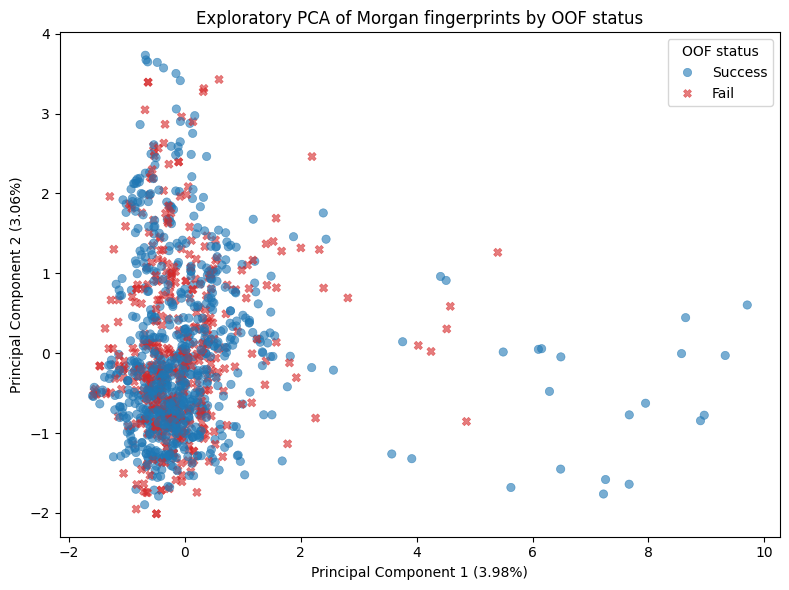

Explained variance ratio: [0.039819163172918955, 0.03057965113832768]
Saved: results\figures\morgan_pca_oof_status.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

prediction_status = np.where(rf_oof_prediction == y, "Success", "Fail")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
pca_frame = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "OOF status": prediction_status,
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=pca_frame, x="PC1", y="PC2", hue="OOF status", style="OOF status",
    markers={"Success": "o", "Fail": "X"},
    palette={"Success": "#1f77b4", "Fail": "#d62728"},
    alpha=0.6, edgecolor=None, ax=ax,
)
explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"Principal Component 1 ({explained[0]:.2f}%)")
ax.set_ylabel(f"Principal Component 2 ({explained[1]:.2f}%)")
ax.set_title("Exploratory PCA of Morgan fingerprints by OOF status")
fig.tight_layout()
pca_path = FIGURES_DIR / "morgan_pca_oof_status.png"
fig.savefig(pca_path, dpi=300, bbox_inches="tight")
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_.tolist())
print(f"Saved: {pca_path.relative_to(PROJECT_ROOT)}")

# 9. t-SNE Exploration

Use the original settings: two dimensions, perplexity 30, `random_state=42`, and `max_iter=1000`. This embedding is exploratory only and is not used by any model.

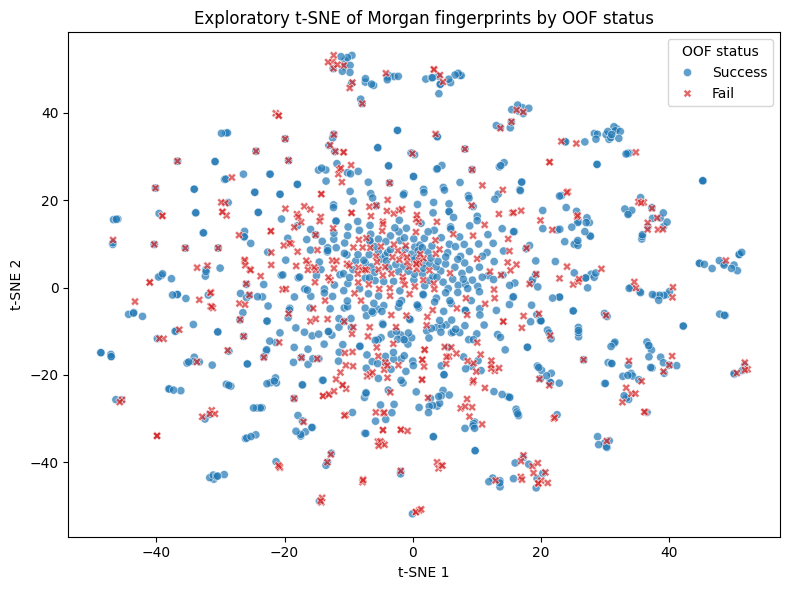

Saved: results\figures\morgan_tsne_oof_status.png


In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X)
tsne_frame = pd.DataFrame({
    "t-SNE 1": X_tsne[:, 0],
    "t-SNE 2": X_tsne[:, 1],
    "OOF status": prediction_status,
}).sort_values("OOF status", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=tsne_frame, x="t-SNE 1", y="t-SNE 2", hue="OOF status", style="OOF status",
    markers={"Success": "o", "Fail": "X"},
    palette={"Success": "#1f77b4", "Fail": "#d62728"},
    alpha=0.7, edgecolor="white", s=35, ax=ax,
)
ax.set_title("Exploratory t-SNE of Morgan fingerprints by OOF status")
fig.tight_layout()
tsne_path = FIGURES_DIR / "morgan_tsne_oof_status.png"
fig.savefig(tsne_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {tsne_path.relative_to(PROJECT_ROOT)}")

# 10. Legacy Results and Methodological Notes

## Historical Notebook 3 / 3-1 Results

These are the values embedded in the original notebooks. They are reference values from the historical workflow, not results from this current reconstruction.

> The historical notebooks were executed on a 1,202-row cohort that is not available for direct row-level verification. The current reconstruction contains 1,198 rows. Therefore, historical and current results are not treated as results from the same cohort.

In [10]:
historical_results = pd.DataFrame([
    {"model": "Random Forest (100 trees)", "n_samples": 1201, "accuracy_mean": 0.6736, "roc_auc_mean": 0.6967, "f1_mean": 0.7559},
    {"model": "LightGBM", "n_samples": 1201, "accuracy_mean": 0.6495, "roc_auc_mean": 0.6684, "f1_mean": 0.7419},
    {"model": "Random Forest (200 trees, depth 10, min split 5)", "n_samples": 1201, "accuracy_mean": 0.6528, "roc_auc_mean": 0.6774, "f1_mean": 0.7747},
])
historical_results

,model,n_samples,accuracy_mean,roc_auc_mean,f1_mean
0,Random Forest (100 trees),1201,0.6736,0.6967,0.7559
1,LightGBM,1201,0.6495,0.6684,0.7419
2,"Random Forest (200 trees, depth 10, min split 5)",1201,0.6528,0.6774,0.7747


## Current Reconstructed Cohort Results

The following table is **5-fold cross-validation performance** (mean and population standard deviation across fold scores). These are not test performance or independent validation performance.

In [11]:
RESULTS_PATH = TABLES_DIR / "morgan_fingerprint_model_comparison.csv"
current_results.to_csv(RESULTS_PATH, index=False)
current_results

,model,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Random Forest (100 trees),1197,0.675872,0.024252,0.688555,0.024885,0.759277,0.018084
1,LightGBM,1197,0.649965,0.020210,0.655476,0.024345,0.743168,0.013361
2,"Random Forest (200 trees, depth 10, min split 5)",1197,0.652479,0.015164,0.679695,0.019196,0.774000,0.007408


## Methodological limitations

- No independent test set was used; CV results are not independent test performance.
- The historical 1,202-row cohort cannot be directly verified, and the current reconstructed cohort has 1,198 input rows (1,197 valid fingerprints).
- The existing depth-limited Random Forest parameters originated from the earlier legacy GridSearch workflow. No nested CV was used for historical model selection; the earlier selection and later CV reporting should not be interpreted as independent evaluation.
- Fingerprints and invalid-SMILES filtering are prepared before CV. Fingerprint generation is deterministic and target-independent; no feature selection or learned preprocessing is applied.
- PCA and t-SNE are exploratory visualizations only. Scaffold counts are descriptive only.

## Reproducibility record

- Input SHA-256: `4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7`
- Current input: 1,198 rows; valid fingerprints: 1,197; invalid SMILES: 1 (DILIST_ID 397)
- Morgan radius: 2; `nBits`: 2,048
- CV: 5-fold `StratifiedKFold(shuffle=True, random_state=42)`
- Result table: `results/tables/morgan_fingerprint_model_comparison.csv`
- OOF error table: `results/tables/morgan_rf_oof_errors.csv`
- Figures: `results/figures/morgan_pca_oof_status.png`, `results/figures/morgan_tsne_oof_status.png`